In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import seaborn as sns
import os
import duckdb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)

In [10]:
cleaned_parquet = "../data/cleaned_data/cleaned_fraud.parquet"

print(f"📊 Original size: {os.path.getsize(cleaned_parquet) / (1024**3):.2f} GB")

con = duckdb.connect()

📊 Original size: 0.14 GB


In [11]:
# Load full dataset
df = con.execute(f"SELECT * FROM '{cleaned_parquet}'").fetch_df()

# 1. EDA & Pattern Detection
print("Original Class Distribution:")
print(df['is_fraud'].value_counts(normalize=True))

# Check for negative time values (Pattern Detection)
neg_time = df[df['time_since_last_transaction'] < 0]
print(f"\nRows with negative time_since_last_transaction: {len(neg_time)}")
if len(neg_time) > 0:
    print("Negative values might indicate data errors or specific flags. Treating as valid numeric for now.")
    
con.close()

Original Class Distribution:
is_fraud
False    0.956244
True     0.043756
Name: proportion, dtype: float64

Rows with negative time_since_last_transaction: 2051331
Negative values might indicate data errors or specific flags. Treating as valid numeric for now.


In [12]:
# We reduce sample size for faster experimentation
import pandas as pd

# Assume df is your full dataset
fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

# Randomly sample equal number of legit cases
legit_sampled = legit.sample(n=len(fraud), random_state=42)

# Combine
df_balanced = pd.concat([fraud, legit_sampled]).sample(frac=1, random_state=42)


In [13]:
df_balanced['is_fraud'].value_counts(normalize=True)

is_fraud
True     0.5
False    0.5
Name: proportion, dtype: float64

In [15]:


# 2. Data Preparation for SMOTE
# - Drop high cardinality identifiers
# - Encode categorical variables
# - Scale numerical variables

categorical_cols = ['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel']
numerical_cols = ['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'hour', 'day_of_week']
drop_cols = ['sender_account', 'receiver_account', 'ip_address', 'device_hash', 'year', 'month', 'day_of_month'] # high-cardinality identifiers that do not generalize well and can negatively affect the model training. Dropping date because we already extracted more meaningful features like hours and days of the week

# Separate Features and Target
# X = df.drop(columns=['is_fraud'] + drop_cols, errors='ignore')
X = df_balanced.drop('is_fraud', axis=1)
y = df_balanced['is_fraud']

# Split Data (Best Practice: Split BEFORE SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratifying by y to ensure both splits have an equal amount of the target variable y

# Preprocessing Pipeline 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)



In [16]:
# 4. Full Pipeline: Preprocess → SMOTE → Model - automatic preprocessing applying SMOTE in CV
smote_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, n_jobs=-1)) # logistic regression uses iterative optimization to find the best coefficients, if max_iter is too low, the model may not fully converge, resulting in suboptimal predictions. n_jobs (-1), means use all available CPU cores for parallel processing
])


In [17]:
# Using a HalvingGridSearchCV 
# We try many versions of our model with different hyperparameters and uses a successive halving strategy
# - Pick the best hyperparameters overall,  find the best model configuration


from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

halving_search = HalvingGridSearchCV(
    estimator=smote_pipeline,
    param_grid=param_grid,
    factor=3,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

halving_search.fit(X_train, y_train) # This takes about 8 mins to run

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 95761
max_resources_: 287284
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 3
n_resources: 95761
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 1
n_candidates: 1
n_resources: 287283
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\J2F\anaconda3\envs\dsi_participant\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


HalvingGridSearchCV(cv=3,
                    estimator=Pipeline(steps=[('preprocess',
                                               ColumnTransformer(transformers=[('num',
                                                                                Pipeline(steps=[('imputer',
                                                                                                 SimpleImputer(strategy='median')),
                                                                                                ('scaler',
                                                                                                 StandardScaler())]),
                                                                                ['amount',
                                                                                 'time_since_last_transaction',
                                                                                 'spending_deviation_score',
                                                                                 'velocity_score',
                                                                                 'geo_anomaly_score',
                                                                                 'hour',
                                                                                 'day_of_week']),
                                                                               ('cat',
                                                                                Pipeline(steps=[('imp...
                                                                                                 OneHotEncoder(handle_unknown='ignore',
                                                                                                               sparse_output=False))]),
                                                                                ['transaction_type',
                                                                                 'merchant_category',
                                                                                 'location',
                                                                                 'device_used',
                                                                                 'payment_channel'])])),
                                              ('smote', SMOTE(random_state=42)),
                                              ('model',
                                               LogisticRegression(max_iter=2000,
                                                                  n_jobs=-1))]),
                    n_jobs=-1,
                    param_grid={'model__C': [0.1, 1, 10],
                                'model__penalty': ['l2'],
                                'model__solver': ['lbfgs']},
                    scoring='f1', verbose=1)

In [18]:
# Best Model
best_pipeline = halving_search.best_estimator_
best_pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amount',
                                                   'time_since_last_transaction',
                                                   'spending_deviation_score',
                                                   'velocity_score',
                                                   'geo_anomaly_score', 'hour',
                                                   'day_of_week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'location', 'device_used',
                                                   'payment_channel'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(C=10, max_iter=2000, n_jobs=-1))])

In [19]:
best_hyperparams = halving_search.best_params_
best_hyperparams

{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

In [20]:
best_score = halving_search.best_score_
best_score

0.5044094612059359

              precision    recall  f1-score   support

       False       0.50      0.50      0.50     35911
        True       0.50      0.50      0.50     35911

    accuracy                           0.50     71822
   macro avg       0.50      0.50      0.50     71822
weighted avg       0.50      0.50      0.50     71822



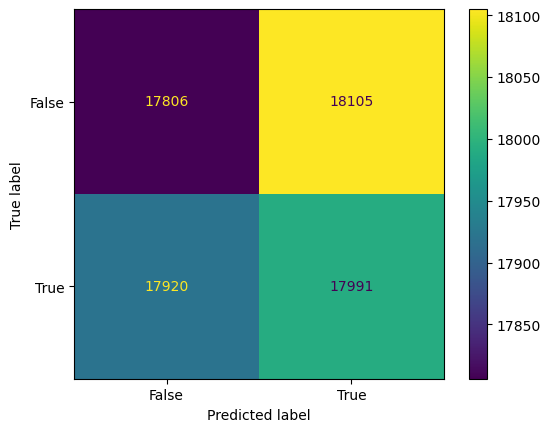

In [21]:
# Evaluate on the realistic test set

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

#  PRediction
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

F1 Score: 0.49970141791770245
Precision: 0.4984208776595745
Recall: 0.500988555038846
PR AUC: 0.4975741891738301

Classification Report:
              precision    recall  f1-score   support

       False       0.50      0.50      0.50     35911
        True       0.50      0.50      0.50     35911

    accuracy                           0.50     71822
   macro avg       0.50      0.50      0.50     71822
weighted avg       0.50      0.50      0.50     71822

ROC AUC: 0.4975044031504714


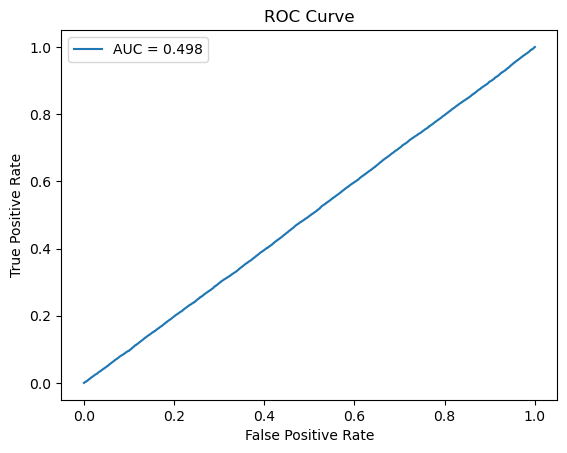

In [28]:
# Evaluate Probability-Based Metrics 
# ROC Curve and AUC

from sklearn.metrics import roc_curve, auc

y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# --- Classification Metrics ---
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

# --- PR AUC ---
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)
print("PR AUC:", pr_auc)

# Optional: full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- ROC AUC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)


plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

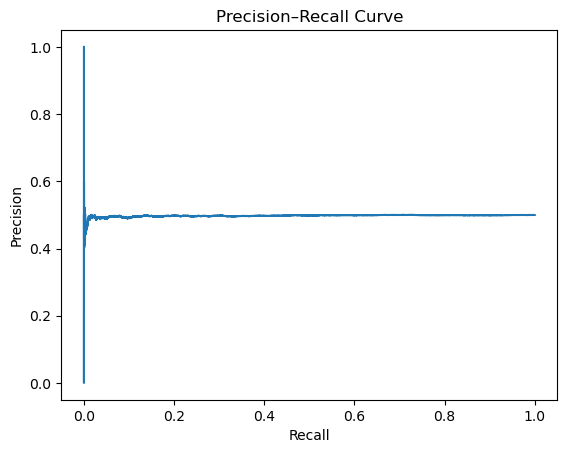

In [30]:
# Precision–Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [ ]:
# Re-run cross-validation on the best model
# This gives a more stable estimate of model performance.

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

scores.mean(), scores.std()

In [ ]:
# Bootstrapping for Confidence Intervals
import numpy as np
from sklearn.metrics import f1_score

boot_scores = []

for i in range(1000):
    idx = np.random.choice(len(y_test), len(y_test), replace=True)
    boot_scores.append(f1_score(y_test.iloc[idx], y_pred[idx]))
    # or y_pred.iloc[idx] if y_pred is also a Series

ci_low = np.percentile(boot_scores, 2.5)
ci_high = np.percentile(boot_scores, 97.5)

ci_low, ci_high

Interpretation
The model’s true F1 score (if you could test it on many alternate samples of fraud data) is likely somewhere between:
- 7.94%
- 8.16%
That’s a very narrow interval, which means:
- The model is stable
- The model is consistently weak at detecting fraud
- The low performance is not due to randomness
- The issue is model capacity, not noise
This matches your earlier cross‑validation result:
- Mean F1 ≈ 0.0805
- Std ≈ 0.0004
Everything is pointing to the same conclusion.


model’s F1 score is ~0.08
This means:
- The model is catching very few fraud cases
- Precision and/or recall are extremely low
- The model is barely better than random guessing for the minority class
In fraud detection, a good F1 is usually 0.3–0.6 depending on difficulty.
An F1 of 0.08 means the model is struggling to identify fraud patterns.

The standard deviation is tiny (~0.0004)
This means:
- The model is consistently bad
- Performance is stable across folds
- The issue is not randomness or variance
- The issue is model capacity or feature signal, not noise
So the model isn’t unstable — it’s just not learning enough from the data

Next, we'd try RandomForest, XGBoost, LightGBM, BalancedRandomForestClassifier
Compare all models side‑by‑side
